In [1]:
# house price prediction model
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
data = pd.read_csv("HousePricePrediction.csv")

In [3]:
data.head()

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0


In [4]:
X = data.drop(columns=["SalePrice", "Id"])
y = data["SalePrice"]

<Axes: xlabel='YearRemodAdd', ylabel='SalePrice'>

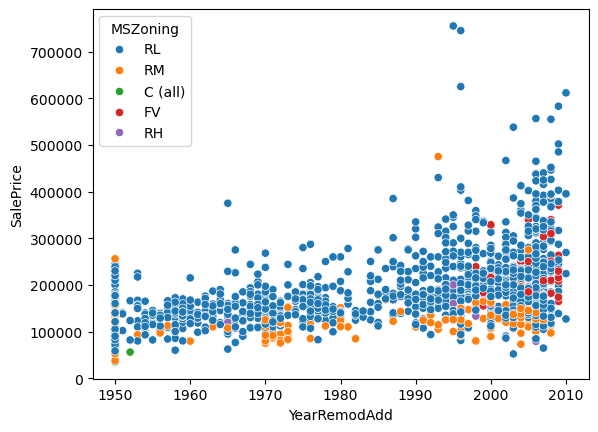

In [5]:
sns.scatterplot(x = data["YearRemodAdd"], y=data["SalePrice"], hue=data["MSZoning"])

In [6]:
# feature engeneering 

# ------------------------------------------------------------
# 1. Data Preparation - Fix Multicollinearity for OLS
# ------------------------------------------------------------
# Plain LR struggles when predictors are highly correlated.
# YearBuilt and YearRemodAdd have a correlation > 0.8 in Ames.
# We drop YearRemodAdd (or you could drop YearBuilt instead).
X_clean = X.drop(columns=['YearRemodAdd'])  

# (Optional alternative: Create an "age at remodel" offset instead)
# X_clean = X.copy()
# X_clean['Years_Remodel_Offset'] = X_clean['YearRemodAdd'] - X_clean['YearBuilt']
# X_clean = X_clean.drop(columns=['YearRemodAdd'])

# ------------------------------------------------------------
# 2. Define Column Groups
# ------------------------------------------------------------
# Numeric columns with heavy right-skew -> will apply log(1+x)
skewed_cols = ['LotArea', 'TotalBsmtSF']

# Numeric columns that are roughly normal/ordinal -> just scale
regular_num_cols = ['YearBuilt', 'OverallCond']  # YearRemodAdd is removed

# Categorical columns -> one-hot encode
cat_cols = ['MSZoning', 'LotConfig', 'BldgType', 'Exterior1st', 'MSSubClass']

# ------------------------------------------------------------
# 3. Build Sub-Pipelines
# ------------------------------------------------------------
# Pipeline for skewed features: Log -> Impute -> Scale
skewed_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),   # <-- impute first
    ('log', FunctionTransformer(np.log1p, validate=True)),
    ('scaler', StandardScaler())
])

# Pipeline for regular numeric: Impute -> Scale
regular_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline for categorical: Impute -> OneHot
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

# ------------------------------------------------------------
# 4. Combine into ColumnTransformer
# ------------------------------------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ('num_skew', skewed_pipeline, skewed_cols),
        ('num_reg',  regular_pipeline, regular_num_cols),
        ('cat',      cat_pipeline, cat_cols)
    ],
    remainder='drop'  # Drops any columns not explicitly listed (e.g., ID columns)
)

# ------------------------------------------------------------
# 5. Create the Complete Modeling Pipeline
# ------------------------------------------------------------
model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [7]:
# Remove rows where target is missing (these are the Kaggle test rows)
mask = y.notna()
X_clean = X[mask]              # Now shape: (1460, 11)
y_clean = y[mask]              # Now shape: (1460,)

# Drop YearRemodAdd for multicollinearity
X_clean = X_clean.drop(columns=['YearRemodAdd'])

# Now split into train/test (for model validation)
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42
)

In [8]:
model_pipeline.fit(X_train, y_train)

# Predict on the test set
y_pred = model_pipeline.predict(X_test)

In [9]:
y_pred

array([152564.85358555, 226757.13456101, 121784.56543581, 178360.84568165,
       244840.99741051,  80231.74563376, 196939.85322637, 113309.68269099,
       105412.94758475, 211268.56909059, 115021.51984707, 151499.79841352,
       149352.5272147 , 225430.77420217, 226271.21341029, 148966.38819465,
       233169.16326733, 146286.26181985, 133611.53437517, 226134.00102924,
       151687.40558672, 243042.86082491, 220156.96121508, 125200.2576509 ,
       209649.45847248, 200968.89602282, 221322.24975382, 167221.67212361,
       235852.67500426, 193635.20456678,  90782.16634718, 248031.87602462,
       200240.94079854, 148115.90216224, 243103.37828189, 145267.515541  ,
       135329.83541531, 231302.78943074, 265239.34174083, 135703.44762574,
       120763.86740218, 222334.95107536, 148516.12995538, 247882.5818958 ,
       151710.76531152,  89533.88020052, 141661.48778327, 143362.54719356,
       316625.34126751, 178655.31301818, 126656.32529713, 169258.20703263,
       161904.30597239, 2

In [10]:
y_test

892     154500.0
1105    325000.0
413     115000.0
522     159000.0
1036    315500.0
          ...   
479      89471.0
1361    260000.0
802     189000.0
651     108000.0
722     124500.0
Name: SalePrice, Length: 292, dtype: float64

In [11]:
# ------------------------------------------------------------
# 7. Evaluate Performance
# ------------------------------------------------------------
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

R² Score: 0.5235
RMSE: 60455.0840


In [12]:
print(f"X shape: {X.shape}")  # Should print (1460, ...)
print(f"y shape: {y.shape}")  # Should print (1460,)

X shape: (2919, 11)
y shape: (2919,)
